## Patient 3455
In this notebook, I will implement all the necessary processing procedures to extract information to analyze the data including visualization to better understand the data. 
Inspired from subjects_loop.ipynb

In [85]:
# TODO: - different subjects_dir directories, solve the directories
#      - trans = mne.transforms.Transform('mri', 'head') inconsistent

### Imports : 

In [86]:
# General Imports
import os
import numpy as np
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import os
from datetime import datetime
import pandas as pd
import numpy as np
import mne
import neo
import imageio

# MNE imports
import mne
from mne.stats import permutation_cluster_test
from mne import Epochs
from mne.time_frequency import EpochsTFRArray
from mne.datasets import fetch_fsaverage
from mne_bids import (
    find_matching_paths,
    read_raw_bids,
)
import mne_bids
from mne_bids import BIDSPath
from mne.datasets import somato

# Neuralset imports
import neuralset # TODO: explore the library and understand how to use it for visualization

# Set up the 3D backend for MNE visualization
matplotlib.use('Agg') # or nbAgg
mne.viz.set_3d_backend('notebook')

'notebook'

### Useful functions :

In [87]:
EXTRA_COLUMNS_DESCRIPTIONS = {
    'stim_onset_unity': 'Stimulus onset time in seconds since the start of the Unity game',
    'resp_onset_unity': 'Response onset time in seconds since the start of the Unity game',
    'duration': 'Duration between stimulus and response in seconds',
    'condition': 'Condition of the trial (Current, Past, Distant Past, Futur, Distant Futur)',
    'correct': 'Whether the response is correct or not (True/False)',
    'validation': 'whether the response is correct or not(Eprime)',
    'stim': 'Stimulus presented to the subject',
    'resp': 'Response given by the subject',
    'correct_year': 'Year that the subject should have answered',
    'year': 'Year during which the subject was asked to answer',
    'cross_time': 'duration of the fixation cross before trial onset',
}

def raw_from_neo(fname):
    seg_micromed = neo.MicromedIO(filename=fname)
    # Date
    date = seg_micromed.raw_annotations['blocks'][0]['rec_datetime']
    print("Date: ", date)
    # Convert the date to UTC
    segment = seg_micromed.read_segment()

    # Because here we have the same on all chan
    sfreq = segment.analogsignals[0].sampling_rate

    data = np.asarray(segment.analogsignals)[0].T
    data *= 1e-6  # putdata from microvolts to volts

    ch_names = [channel[0] for channel in seg_micromed.header['signal_channels']]
    ch_types = ['stim' if 'MKR' in ch_name else 'ecg' if 'ECG' in ch_name else 'misc' if 'EX' in ch_name else 'stim' if 'PHOTO' in ch_name else 'stim' if 'photo' in ch_name else 'seeg' for ch_name in ch_names]
 
    info = mne.create_info(ch_names, sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data, info)
    return(raw)


def seeg_ch_name_split(name):
    elec, idx = re.match(r'([A-Za-z]+)(\d+)', name).groups()
    return elec, int(idx)


def find_anodes_cathodes(raw):
    anodes, cathodes = [], []
    for i in range(len(raw.ch_names)-1):
        if raw.get_channel_types()[i:i+2]==['seeg', 'seeg']:
            (e1, i1), (e2, i2) = map(seeg_ch_name_split, raw.ch_names[i:i+2])
            if e1==e2:
                anodes.append(e1 + str(i1))
                cathodes.append(e2 + str(i2))
    return (anodes, cathodes)


def read_montage(subject, subjects_dir):
    # ii. import electrodes
    ch_coords_df = pd.read_csv(os.path.join(subjects_dir, subject, 'elec_recon', subject + '.PIAL'), sep=' ', header=1)
    ch_coords = ch_coords_df[['R', 'A', 'S']].to_numpy(dtype=float)/1000. # put in mm
    ch_names_df = pd.read_csv(os.path.join(subjects_dir, subject, 'elec_recon', subject + '.electrodeNames'), sep=' ', header=1, names=['name', 'Depth', 'hemisphere'])
    ch_names = ch_names_df['name'].tolist()
    ch_pos = dict(zip(ch_names, ch_coords))
    lpa, nasion, rpa = mne.coreg.get_mni_fiducials(subject, subjects_dir=subjects_dir)
    lpa, nasion, rpa = lpa['r'], nasion['r'], rpa['r']
    montage_head = mne.channels.make_dig_montage(ch_pos, coord_frame='mri', nasion=nasion, lpa=lpa, rpa=rpa)
    return(montage_head)


def read_events(fname):
    dicts = list()
    with open(fname) as f:
        content = f.readlines()
        for line in content:
            if line.startswith("UniqueID"):
                ID, Q, year, stim, _, _, _, resp, correct_year, validation, Game, cross_time, stim_onset, resp_time, resp_onset = line.split(" | ")
                
                ID = int(ID.split(":")[1])
                Q = int(Q.split("#")[1])
                year = int(year.split(":")[1])
                stim = stim.split(":")[1]
                resp = resp.split(":")[1].split("(")[0].strip()
                correct_year = correct_year.split(":")[1].strip()
                validation = validation.split(":")[1]
                Game = Game.split("#")[1]
                cross_time = float(cross_time.split(":")[1])
                stim_onset = datetime.strptime(stim_onset.split("displayed:")[1].strip(), "%H:%M:%S:%f")
                resp_time = float(resp_time.split(":")[1])
                resp_onset = datetime.strptime(resp_onset.split("answered:")[1].strip(), "%H:%M:%S:%f")
                data ={
                        "ID": ID,
                        "Q": Q,
                        "year": year,
                        "stim": stim,
                        "resp": resp,
                        "correct_year": correct_year,
                        "validation": validation,
                        "Game": Game,
                        "cross_time": cross_time,
                        "stim_onset": stim_onset,
                        "resp_time": resp_time,
                        "resp_onset": resp_onset
                    }
                dicts.append(data)

    unity_start = content[0].split('|')[0].split('Time:')[1].strip()
    unity_start = datetime.strptime(unity_start, "%H:%M:%S:%f")

    first_photo = content[2].split('completed:')[1].strip()
    first_photo = datetime.strptime(first_photo, "%H:%M:%S:%f")

    df = pd.DataFrame(dicts)

    df['stim_onset_unity'] = df['stim_onset'] - unity_start
    df['stim_onset_unity'] = [stim.total_seconds() for stim in df['stim_onset_unity']]
    df['resp_onset_unity'] = df['resp_onset'] - unity_start
    df['resp_onset_unity'] = [resp.total_seconds() for resp in df['resp_onset_unity']]
    df['duration'] = df['resp_onset_unity'] - df['stim_onset_unity']

    conditions = []
    correct = []
    for r, row in df.iterrows():
        current_year = row['year']
        correct_year = row['correct_year']
        resp = row['resp']
        # Condition
        if correct_year in ['Never', 'Always']:
            condition = correct_year
        else:
            distance = int(correct_year) - int(current_year)
            if distance == 0:
                condition = "Current"
            elif distance == -1:
                condition = "Past"
            elif distance  < -1:
                condition = "Distant Past"
            elif distance == 1:
                condition = "Futur"
            elif distance > 1:
                condition = "Distant Futur"
        conditions.append(condition)

        if resp == 'C':
            response = 'Current'
        elif resp == 'A':
            response = 'Always'
        elif resp == 'N':
            response = 'Never'
        elif resp == '+1':
            response = 'Futur'
        elif resp == '-1':
            response = 'Past'
        elif resp == '+2':
            response = 'Distant Futur'
        elif resp == '-2':
            response = 'Distant Past'
        else:
            raise ValueError(f"Unknown response: {resp}")
        
        if response == condition:
            correct.append(True)
        else:
            correct.append(False)

    df['condition'] = conditions
    df['correct'] = correct
    df['validation'] = df['validation'].astype(bool)

    return(df)

### Parameters :

In [ ]:
# Choose between TRC data or BIDS data
data_source = "TRC" # "TRC" or "BIDS" or "Check" (for comparing outputs of both)(If check chosen, notebook will be executed with TRC data)

# Electrode Referencing type
# TODO: implement all referencing 
reference = "bipolar" # "bipolar" or "bipolar_shaft" or "no_reference" or "average" or "all" (with no video rendering)

# Video rendering
video_rendering = True # can be long, so do not do it if not needed
nb_videos = 3 # number of videos to render (usually low to test the pipeline)

# BIDS data already loaded
loaded = False # Can take up ot 15min

# TODO - solve the patient and subject variables, maybe create a mapping between them
patient = "PAT_3455"
subject = "02"

# Interval around stimulus onset to epoch the data
tmin = -1
tmax = 7 
PAD = 0.5


# Patient directory
if subject == "01":
    experiment_dir = fr"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PatientHL1996/Experiment_997996.txt"
    trc_dir = fr"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PatientHL1996/EEG_870458.TRC"
if subject == "02":
    experiment_dir = fr"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/stims/sub-02/P2/Unity_experiment/Experiment_698092.txt"
    trc_dir = r"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/seeg/sub-02/PA_1987/EEG_6865.TRC"


# Check parameters
if data_source not in ["BIDS", "TRC", "Check"]:
    raise ValueError("Data source must be either TRC or BIDS (or Check)")

### Data loading and processing

The next cell will: 
- load the data
- clean the channel names 
- adjust stimulus onset timing
- filter out behaviorally incorrect trials
- crop the signal (and index it correctly)
- integrate annotations of the conditions
- check bad annotation path
- read electrode coordinates and get the montage (and save it) and set it to the raw data
- get volume labels (for electrodes characterization)
- create some vizualisation of the electrodes


In [89]:
# BIDS root
bids_root = Path("/media/RCPNAS/sEEG_MARS_Alison")

# FreeSurfer subjects directory - contains reconstructions for all patients, including PAT3390
fs_subjects_dir = Path("/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions") 

# Check participants.tsv for mapping
participants_file = bids_root / "participants.tsv"
if participants_file.exists():
    participants = pd.read_csv(participants_file, sep='\t')
    print("Participants mapping:")
    print(participants)

# Verify the PAT3390 subject exists
pat_path = fs_subjects_dir / patient
print(f"PAT path exists: {pat_path.exists()}")
if pat_path.exists():
    print("Found FreeSurfer subject PAT with directories:")
    print([d.name for d in pat_path.iterdir() if d.is_dir()])

# TODO: Now create mapping for all subjects
subject_to_fs = {
    "01": "PAT_3390",
    "02": "PAT_3455"
}

# Process sub-02
session = "retrieval"
task = "mars"
fs_subject = subject_to_fs[subject]
print(f"\nProcessing {subject} → FreeSurfer subject: {fs_subject}")
print(f"FreeSurfer directory: {fs_subjects_dir / fs_subject}")

# Create BIDS path from bids_root
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    datatype="ieeg",
    root=bids_root,
    suffix="ieeg",
    extension=".vhdr"
)

if loaded == False : # Skip the loading step if the data is already loaded and cleaned
    # Read data
    if data_source == "BIDS" or data_source == "Check":
        print(f"\nLoading data from: {bids_path.fpath}")
        raw = read_raw_bids(bids_path, verbose=False)
        raw_bids = raw.copy()

    if data_source == "TRC" or data_source == "Check":
        fname_events = experiment_dir
        fname_raw = trc_dir

        print(f"\n--- Traitement TRC ---")
        df = read_events(fname_events)
        raw = raw_from_neo(fname_raw)

        if 'photo' in raw.ch_names:
            raw.rename_channels({'photo': 'photodiode'})
        if 'PHOTO' in raw.ch_names:
            raw.rename_channels({'PHOTO': 'photodiode'})
        
        if 'ECG-' in raw.ch_names and 'ECG+' in raw.ch_names:
            raw = mne.set_bipolar_reference(raw, 'ECG-', 'ECG+', ch_name='ECG', drop_refs=True)
            raw.set_channel_types({'ECG': 'ecg'})

        if subject == "01":
            negPhotoSig = raw.get_data(picks=['photodiode'])[0] <-0.003

            # Get suspected beginning and end of fixation cross
            mrkTCbeg = np.where(np.diff(np.int64(negPhotoSig),n=1)>0)[0]
            mrkTCend = np.where(np.diff(np.int64(negPhotoSig),n=1)<0)[0]

            onsets  = []
            durations = []

            for onset, end in zip(mrkTCbeg, mrkTCend):
                duration = (end - onset) / raw.info['sfreq']
                if duration > 1.6 and duration < 2.4:
                    if onset > 1546240.0:
                        onsets.append(onset / raw.info['sfreq'])
                        durations.append(duration)

            delay = np.abs(onsets[0] - df['resp_onset_unity'].values[0])
            df['stim_onset_abs'] = df['stim_onset_unity'] + delay
            df['resp_onset_abs'] = df['resp_onset_unity'] + delay
            
            tmin_abs = 700
            tmax_abs = 1600
        
        if subject == "02":
            delay = (1844.475 - 333.112) # TODO: Comment est calculé ce délai?
            df['stim_onset_abs'] = df['stim_onset_unity'] + delay
            df['resp_onset_abs'] = df['resp_onset_unity'] + delay

            tmin_abs = 1600
            tmax_abs = 3200
        
        print(f"Original signal length : {raw.times[-1]:.2f}s")
        raw.crop(tmin=tmin_abs, tmax=tmax_abs)
        print(f"Length after crop ({tmin_abs}-{tmax_abs}) : {raw.times[-1]:.2f}s")

        raw = raw.copy() 

        mask = (df['stim_onset_abs'] >= tmin_abs) & (df['stim_onset_abs'] <= tmax_abs)
        df_filtered = df[mask].reset_index(drop=True)

        # Keep only correct trials
        df_filtered = df_filtered[df_filtered['correct'] == True].reset_index(drop=True)
        print(f"Correct trials: {len(df_filtered)} / {mask.sum()}")
        
        
        if len(df_filtered) == 0:
            print(f"ERREUR CRITIQUE : Aucun événement ne tombe dans la fenêtre [{tmin_abs}, {tmax_abs}]s !")
            print(f"Vérifiez vos colonnes 'stim_onset_unity' et le délai calculé ({delay}).")
            print(f"Min stim_onset_abs: {df['stim_onset_abs'].min()}, Max: {df['stim_onset_abs'].max()}")
        else:
            df_filtered['onset_rel'] = df_filtered['stim_onset_abs'] - tmin_abs
            
            onsets = df_filtered['onset_rel'].values
            durations = df_filtered['duration'].values
            descriptions = df_filtered['condition'].values

            valid_idx = ~np.isnan(onsets) & ~np.isnan(durations)
            onsets = onsets[valid_idx]
            durations = durations[valid_idx]
            descriptions = descriptions[valid_idx]

            annotations = mne.Annotations(
                onset=onsets,
                duration=durations,
                description=descriptions.astype(str)
            )
            
            raw.set_annotations(annotations)

            print(f"Nombre d'annotations dans l'objet raw : {len(raw.annotations)}")
            if len(raw.annotations) > 0:
                print(f"Exemple d'annotation : {raw.annotations[0]}")
            else:
                print("ÉCHEC : Les annotations n'ont pas été enregistrées malgré la création.")

        raw_trc = raw.copy()

    trc_channel_names = raw.ch_names
    print(f"TRC channel names (first 10): {trc_channel_names[:10]}")
    print(f"Total channels: {len(trc_channel_names)}")


    # Path to electrode reconstruction files
    elec_recon_path = bids_root / "sourcedata" / "reconstructions" / patient / "elec_recon"
    coord_type = "LEPTO"  # Use LEPTO !!!!!
    coord_file = elec_recon_path / f"{patient}.{coord_type}"
    print(f"\nLoading coordinates from: {coord_file}")
    print(f"File exists: {coord_file.exists()}")

    # Load bad annotations
    bad_annotation_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_annot.csv"

    if bad_annotation_path.exists():
        # Check if file is empty (size 0) or has only headers
        if bad_annotation_path.stat().st_size == 0:
            print(f"Warning: {bad_annotation_path} is empty. Skipping.")
            bad_annotations = mne.Annotations(onset=[], duration=[], description=[], orig_time=raw.annotations.orig_time)
        else:
            try:
                # Try reading with pandas first to check content
                df_test = pd.read_csv(bad_annotation_path)
                if df_test.empty:
                    print(f"Warning: {bad_annotation_path} has no data rows. Skipping.")
                    bad_annotations = mne.Annotations(onset=[], duration=[], description=[], orig_time=raw.annotations.orig_time)
                else:
                    # File has data, proceed with MNE
                    bad_annotations = mne.read_annotations(bad_annotation_path)
                    
                    # # Sync orig_time if needed
                    # if raw.annotations.orig_time is not None:
                    #     bad_annotations = mne.Annotations(
                    #         onset=bad_annotations.onset,
                    #         duration=bad_annotations.duration,
                    #         description=bad_annotations.description,
                    #         orig_time=raw.annotations.orig_time
                    #     )
            except Exception as e:
                print(f"Error reading {bad_annotation_path}: {e}")
                bad_annotations = mne.Annotations(onset=[], duration=[], description=[], orig_time=raw.annotations.orig_time)

        # Add to raw
        # raw.set_annotations(raw.annotations + bad_annotations)
        raw.annotations.append(
            onset=bad_annotations.onset,
            duration=bad_annotations.duration,
            description=bad_annotations.description
        )
        print(f"Added {len(bad_annotations)} bad segments.")


    # Clean the coordinates and creates a montage that matches the TRC channels
    if coord_file.exists():
        # Read the coordinate file
        # These are typically text files with coordinates in mm
        coords = []
        with open(coord_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith('#'):  # Skip empty lines and comments
                    try:
                        # Parse x y z coordinates
                        parts = line.split()
                        if len(parts) >= 3:
                            x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
                            coords.append([x, y, z])
                    except:
                        continue
        
        coords = np.array(coords)
        print(f"Loaded {len(coords)} coordinates")
        
        # Also load electrode names if available
        names_file = elec_recon_path / f"{patient}.electrodeNames"
        if names_file.exists():
            with open(names_file, 'r') as f:
                electrode_names = [line.strip() for line in f if line.strip() and not line.startswith('#')]
            print(f"Loaded {len(electrode_names)} electrode names")
        else:
            electrode_names = [f"ELEC{i+1:03d}" for i in range(len(coords))]
        
        # Check if number matches TRC channels
        print(f"\nCoordinate count: {len(coords)}")
        print(f"TRC channel count: {len(trc_channel_names)}")
        print(f"Electrode names count: {len(electrode_names)}")
        
        if len(coords) == len(trc_channel_names):
            print(" Coordinate count matches TRC channels - using as-is")
            montage_coords = coords
            montage_names = trc_channel_names
        else:
            print(" Count mismatch - need to map coordinates to TRC channels")
            
            # Create mapping dictionary
            coord_dict = dict(zip(electrode_names, coords))
            
            # Map to TRC order
            montage_coords = []
            montage_names = []
            
            for ch_name in trc_channel_names:
                # Try exact match first
                if ch_name in coord_dict:
                    montage_coords.append(coord_dict[ch_name])
                    montage_names.append(ch_name)
                else:
                    # Try without spaces/special chars
                    ch_clean = ch_name.replace(' ', '').replace('-', '').replace("'", "")
                    found = False
                    for coord_name in coord_dict.keys():
                        coord_clean = coord_name.replace(' ', '').replace('-', '').replace("'", "")
                        if ch_clean in coord_clean or coord_clean in ch_clean:
                            montage_coords.append(coord_dict[coord_name])
                            montage_names.append(ch_name)
                            print(f"  Matched {ch_name} to {coord_name}")
                            found = True
                            break
                    
                    if not found:
                        print(f"  Warning: No match for {ch_name}")
                        montage_coords.append([np.nan, np.nan, np.nan])
                        montage_names.append(ch_name)
            
            montage_coords = np.array(montage_coords)
        montage_coords = montage_coords / 1000  # Convert mm to m for MNE
        
        # Create montage
        montage = mne.channels.make_dig_montage(
            ch_pos=dict(zip(montage_names, montage_coords)),
            coord_frame='mri'  # These are in MRI coordinates
        )
        
        # Set montage to raw
        raw.set_montage(montage)
        print(f"\n✓ Created montage with {len(montage_names)} electrodes")
        
        # Verify first few electrodes
        print("\nFirst 10 electrode positions:")
        for i, ch_name in enumerate(montage_names[:10]):
            pos = montage.get_positions()['ch_pos'][ch_name]
            print(f"  {ch_name}: ({pos[0]}, {pos[1]:.1f}, {pos[2]:.1f})")
        
        # Save montage for future use
        montage_path = Path.cwd() / f"sub-{subject}_montage.fif"
        montage.save(montage_path, overwrite=True)
        print(f"Saved montage to {montage_path}")
        
        # Now you can get volume labels if FreeSurfer subject exists
        fs_subject = patient
        subjects_dir = bids_root / "sourcedata" / "reconstructions"
        
        aparcaseg_path = f"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/{patient}/mri/aparc+aseg.mgz"

        if Path(aparcaseg_path).exists():
            try:
                labels, colors = mne.get_montage_volume_labels(
                    montage,
                    patient,
                    subjects_dir=str(subjects_dir),
                    aseg="aparc+aseg"
                )
                
                # labels and colors are dicts keyed by channel name
                # Build DataFrame from the dicts directly
                results_df = pd.DataFrame({
                    'channel': list(labels.keys()),
                    'label': [labels[ch] for ch in labels.keys()],
                    'color': [colors[ch] for ch in labels.keys()]
                })
                
                output_path = Path.cwd() / f"sub-{subject}_electrode_labels.csv"
                results_df.to_csv(output_path, index=False)
                print(f"Saved electrode labels to {output_path}")
                print(results_df.head())
                
            except Exception as e:
                print(f"Could not get volume labels: {e}")

    if coord_file.exists() == False:
        montage = None

    # Now visualize electrodes on brain
    print(f"\nCreating brain visualization for {fs_subject}")

    # Create brain
    brain = mne.viz.Brain(
        fs_subject,
        subjects_dir=str(fs_subjects_dir),
        cortex="low_contrast",
        alpha=0.25,
        background="white",
        figure=1,
    )

    # Add electrodes if montage exists
    if montage is not None:
        try:
            # TODO: Check the transform
            trans = mne.transforms.Transform('head', 'mri')  # TODO: Why does the inverse trans give the same result
            brain.add_sensors(raw.info, trans=trans)
            print("Added electrodes to brain")
        except Exception as e:
            print(f"Could not add electrodes: {e}")

    print(f"Montage exists: {montage is not None}")

    if montage is None:
        print("\nNo montage found in raw data.")
        print("Looking for electrodes.tsv file...")
        
        # Look for electrodes.tsv
        electrodes_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_electrodes.tsv"
        print(f"Electrodes file exists: {electrodes_path.exists()}")
        
        if electrodes_path.exists():
            # Read electrodes.tsv
            electrodes_df = pd.read_csv(electrodes_path, sep='\t')
            print(f"\nElectrodes file contents:")
            print(f"Columns: {electrodes_df.columns.tolist()}")
            print(f"Number of electrodes: {len(electrodes_df)}")
            print("\nFirst few electrodes:")
            print(electrodes_df.head())
            
            # Check coordinate columns
            coord_cols = ['x', 'y', 'z']
            if all(col in electrodes_df.columns for col in coord_cols):
                print("\n✓ Found coordinate columns (x, y, z)")
                
                # Create montage
                montage = mne.channels.make_dig_montage(
                    ch_pos=dict(zip(electrodes_df['name'], 
                                electrodes_df[coord_cols].values)),
                    coord_frame='mri'  # or 'head' - check which one
                )
                raw.set_montage(montage)
                print(f"Created and set montage with {len(electrodes_df)} electrodes")
            else:
                print(f"Expected coordinate columns not found. Available columns: {electrodes_df.columns.tolist()}")
        else:
            print("No electrodes.tsv file found in BIDS directory")
            
            # Look for alternative coordinate files
            coord_files = list(Path(bids_root / f"sub-{subject}").rglob("*coord*"))
            print(f"Alternative coordinate files found: {coord_files}")

    # Save images
    output_dir = Path.cwd() / "figures" / f"{subject}"
    output_dir.mkdir(exist_ok=True)
    
    # Save different views
    views = [
        ("lateral_right", dict(azimuth=90, elevation=90, distance=400)),
        ("lateral_left", dict(azimuth=-90, elevation=90, distance=400)),
        ("top", dict(azimuth=0, elevation=90, distance=400)),
        ("front", dict(azimuth=0, elevation=0, distance=400)),
        ("back", dict(azimuth=180, elevation=0, distance=400)),
    ]

    for view_name, view_kwargs in views:
        brain.show_view(**view_kwargs)
        output_file = output_dir / "electrodes" /f"{subject}_electrodes_{view_name}.png"
        brain.save_image(str(output_file))
        print(f"Saved: {output_file}")

    brain.close()
    print(f"\nAll images saved to {output_dir}")

if loaded == True:
    #TODO: Get the data from the corresponding path
    empty = 0

Participants mapping:
  participant_id  age  sex  hand  weight  height
0         sub-01  NaN  NaN   NaN     NaN     NaN
1         sub-02  NaN  NaN   NaN     NaN     NaN
2         sub-03  NaN  NaN   NaN     NaN     NaN
3         sub-04  NaN  NaN   NaN     NaN     NaN
4         sub-06  NaN  NaN   NaN     NaN     NaN
PAT path exists: True
Found FreeSurfer subject PAT with directories:
['mri', 'tmp', 'stats', 'surf_old', 'touch', 'trash', 'surf', 'voxeloc', 'elec_recon_pierre_voxeloc', 'label', 'bem', 'mri_old', 'scripts', 'elec_recon', 'label_old', 'elec_recon_old']

Processing 02 → FreeSurfer subject: PAT_3455
FreeSurfer directory: /media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455

--- Traitement TRC ---
Date:  2022-06-18 09:29:27
Creating RawArray with float64 data, n_channels=121, n_times=8601728
    Range : 0 ... 8601727 =      0.000 ...  4200.062 secs
Ready.
sEEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=86017

/tmp/ipykernel_3698514/3546543649.py:282: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage)
/tmp/ipykernel_3698514/3546543649.py:282: RuntimeWarning: Not setting positions of 4 ecg/stim channels found in montage:
['MKR1+', 'photodiode', 'MKR2+', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage)
/tmp/ipykernel_3698514/3546543649.py:293: RuntimeWarning: This filename (/home/aboschun/MIPlab-Project/sub-02_montage.fif) does not conform to MNE naming conventions. All montage files should end with -dig.fif or -dig.fif.gz
  montage.save(montage_path, overwrite=True)


Could not get volume labels: 'AD1'

Creating brain visualization for PAT_3455


Channel types::	seeg: 116
Added electrodes to brain
Montage exists: True
Saved: /home/aboschun/MIPlab-Project/figures/02/electrodes/02_electrodes_lateral_right.png
Saved: /home/aboschun/MIPlab-Project/figures/02/electrodes/02_electrodes_lateral_left.png
Saved: /home/aboschun/MIPlab-Project/figures/02/electrodes/02_electrodes_top.png
Saved: /home/aboschun/MIPlab-Project/figures/02/electrodes/02_electrodes_front.png
Saved: /home/aboschun/MIPlab-Project/figures/02/electrodes/02_electrodes_back.png

All images saved to /home/aboschun/MIPlab-Project/figures/02


In [90]:
# If wanted, compare the BIDS and TRC raw files to verify they are consistent
# Annotations fail if not executed
if data_source == "TRC" or data_source == "Check":
    raw.set_annotations(annotations)
    raw.annotations
    if data_source == "Check":
        # Compare BIDS and TRC raw files
        print(raw_bids)
        print(raw_trc)
        # Verify what actually matters
        print(f"Sfreq:    BIDS={raw_bids.info['sfreq']}, TRC={raw_trc.info['sfreq']}")
        print(f"N times:  BIDS={len(raw_bids.times)}, TRC={len(raw_trc.times)}")
        print(f"N ch:     BIDS={len(raw_bids.ch_names)}, TRC={len(raw_trc.ch_names)}")
        print(f"Ch match: {raw_bids.ch_names == raw_trc.ch_names}")
        print(f"Ch types match: {raw_bids.get_channel_types() == raw_trc.get_channel_types()}")

#### Check montage's electrodes positions and visualize them (all electrodes):

In [91]:
# Get transform and figure
trans = mne.transforms.Transform('mri', 'head')
fig = mne.viz.plot_alignment(
    raw.info,
    trans=trans,         
    subject=fs_subject,
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

# Get picks and brain volume
picks_hip = mne.pick_channels(raw.info['ch_names'], include=montage.ch_names)

brain = mne.viz.Brain(
    fs_subject,
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=str(fs_subjects_dir), 
    units="m",
    figure=fig,
)
#brain.add_volume_labels(aseg="aparc+aseg", labels=regions_of_interest)

# Add electrode labels
info_hip = mne.pick_info(raw.info, sel=picks_hip)
brain.add_sensors(info_hip, trans=trans)
for idx in picks_hip:
    ch = raw.info['chs'][idx]
    pos = ch['loc'][:3]  # x, y, z in head coords
    brain.plotter.add_point_labels(
        points=[pos],
        labels=[raw.info['ch_names'][idx]],
        point_size=0,
        font_size=12,
        text_color="white",
        shape=None,
        render=False,
    )

# Set and Save views
distance = 0.1
focalpoint = (0.03,-0.0311,0.001)

brain.show_view(azimuth=120, elevation=90)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_alldata01.png")

brain.show_view(azimuth=60, elevation=90)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_alldata02.png")

brain.show_view(azimuth=60, elevation=45)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_alldata03.png")

brain.show_view(azimuth=0, elevation=45)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_alldata04.png")

brain.show_view(azimuth=30, elevation=45)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_alldata05.png")

Channel types::	seeg: 116


A view with name (P_0x7fd301cf0b90_1) is already registered
 => returning previous one


Channel types::	seeg: 116


#### Keep electrodes that are relevant to our study (hippocampus region) :

Important cell where we choose the electrode we will use for our analysis

In [92]:
aseg = "aparc+aseg"  # parcellation/anatomical segmentation atlas
path_atlas = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions"

# Get volume labels for each electrode based on the montage and FreeSurfer subject
labels, colors = mne.get_montage_volume_labels(
    montage, patient, subjects_dir=path_atlas, aseg=aseg
)
print(f"Labels: {labels}")

# Separate by electrodes which have names like LAMY 1
electrodes = set(
    [
        "".join([lttr for lttr in ch_name if not lttr.isdigit() and lttr != " "])
        for ch_name in montage.ch_names
    ]
)
print(f"Electrodes in the dataset: {electrodes}")

# Define regions of interest (ROIs) to keep
regions_of_interest = {
    "ctx-rh-parahippocampal",
    "ctx-rh-fusiform",
    "Right-Hippocampus",
    "ctx-lh-parahippocampal",
    "ctx-lh-fusiform",
    "Left-Hippocampus",
}

# Get labels that correspond to the ROIs --> electrodes that are in the regions of interest
filtered_labels = {
    ch: region_list
    for ch, region_list in labels.items()
    if any(r in regions_of_interest for r in region_list)
}

print(f"Kept {len(filtered_labels)}/{len(labels)} electrodes")
for ch, regions in filtered_labels.items():
    if "Right-Cerebral-White-Matter" in regions:
        regions.remove("Right-Cerebral-White-Matter")
    if "Left-Cerebral-White-Matter" in regions:
        regions.remove("Left-Cerebral-White-Matter")
    print(f"  {ch}: {regions}")


# New set of electrodes that have labels in the ROIs
filtered_electrodes = set([ch.split(" ")[0] for ch in filtered_labels.keys()])
filtered_channels = list(filtered_labels.keys()) 

# Plot their ROIs
fig, ax = mne.viz.plot_channel_labels_circle(filtered_labels, colors, picks=list(filtered_electrodes))
fig.text(0.3, 0.9, "Anatomical Labels", color="white")
fig.savefig(f"figures/{subject}/electrodes/{subject}_allelec_labels.png", dpi=300)

Labels: OrderedDict({'AD1': ['Right-Cerebral-White-Matter', 'Right-Amygdala'], 'AD2': ['Right-Cerebral-White-Matter'], 'AD3': ['Right-Cerebral-White-Matter'], 'AD4': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD5': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD6': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD7': [], 'AD8': [], 'HAD1': ['Right-Cerebral-White-Matter', 'Right-Hippocampus'], 'HAD2': ['Right-Cerebral-White-Matter', 'Right-Hippocampus'], 'HAD3': ['Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent', 'Right-Hippocampus'], 'HAD4': ['Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent', 'Right-Hippocampus', 'ctx-rh-fusiform'], 'HAD5': ['Unknown', 'Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent'], 'HAD6': ['Right-Cerebral-White-Matter'], 'HAD7': ['Right-Cerebral-White-Matter'], 'HAD8': ['Right-Cerebral-White-Matter', 'ctx-rh-inferiortemporal'], 'HAD9': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'HAD10': ['Right-Cerebr

## Filter the raw data

This cell will filter the raw data through a standard procedure:
- Bandpass filter between 0.1Hz and 250Hz
- Remove power line noise and harmonics

In [93]:
raw_filtered = raw.copy().pick_channels(filtered_electrodes) # TODO : test with all electrodes
# Filter raw signals
raw_filtered.load_data()

# band-pass filter 0.1 < 250 Hz
raw_filtered.filter(.1, 250, picks='seeg', fir_design='firwin', n_jobs=9)

# remove power line 50 Hz and harmonics
for ifreq in np.arange(50, 251, 100): # TODO: might be sufficient to filter every 100Hz
    raw_filtered.notch_filter(ifreq, 
                     picks='seeg', 
                     notch_widths=4,
                     method='iir', 
                     iir_params={'order':6, 'ftype':'butter'},
                     n_jobs=9)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 2.5e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 250.00 Hz
- Upper transition bandwidth: 62.50 Hz (-6 dB cutoff frequency: 281.25 Hz)
- Filter length: 67585 samples (33.000 s)



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    8.6s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    9.1s remaining:    2.8s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 48 - 52 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)


[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    9.5s finished


- Cutoffs at 47.50, 52.50 Hz: -6.02, -6.02 dB



...

[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    3.6s finished


Setting up band-stop filter from 1.5e+02 - 1.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 147.50, 152.50 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    2.0s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    2.3s remaining:    0.7s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    2.5s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 2.5e+02 - 2.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 247.50, 252.50 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    1.9s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    2.3s remaining:    0.7s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    2.5s finished


In [94]:
# Sanity check
raw_filtered.annotations

<Annotations | 102 segments: Always (20), Current (17), Distant Futur ...>

## Map the events to the corresponding conditions

For each stimulus exposition, we need to link it to the corresponding condition (current, past, ...):

In [95]:
if data_source == "BIDS":
    print("BIDS")
    annot_df = raw_filtered.annotations.to_data_frame()
    # Create event id from macthing description and condition
    print(annot_df['description'])
    print(annot_df['condition'])

    event_id_for_events = {}
    for desc, cond in zip(annot_df['description'], annot_df['condition']):
        if cond not in event_id_for_events and cond in ['Current', 'Past', 'Distant Past', 'Futur', 'Distant Futur', 'Always', 'Never']:
            event_id_for_events[str(desc)] = int(desc)  # Assign a unique integer ID
    print(f"Event ID mapping: {event_id_for_events}")

    events, _ = mne.events_from_annotations(
        raw_filtered, 
        event_id={k: v for k, v in event_id_for_events.items()}
    )

    # Change events to correct conditions
    event_id = {}
    for desc, cond in zip(annot_df['description'], annot_df['condition']):
        if cond not in event_id and cond in ['Current', 'Past', 'Distant Past', 'Futur', 'Distant Futur', 'Always', 'Never']:
            event_id[str(cond)] = int(desc)  # Assign a unique integer ID
    
    #print(f"Event ID mapping: {event_id}")
    #print(f"Events : {events}")

elif data_source == "TRC" or data_source == "Check":
    print("TRC")
    annot_df = df.copy()
    valid_conds = annot_df['condition'].unique() # Get condition labels in appearing order
    event_id = {str(cond): i+1 for i, cond in enumerate(valid_conds)} # Assign ids based on condition labels

    events, _ = mne.events_from_annotations(
        raw_filtered, 
        event_id={k: v for k, v in event_id.items()}
    )
    
    

TRC
Used Annotations descriptions: [np.str_('Always'), np.str_('Current'), np.str_('Distant Futur'), np.str_('Distant Past'), np.str_('Futur'), np.str_('Never'), np.str_('Past')]


In [96]:
# Check length of events
if data_source == "TRC" or data_source == "Check":
    print("TRC")
    t0 = annot_df['stim_onset'].iloc[0]
    tf = annot_df['stim_onset'].iloc[-1]
    print((tf-t0).total_seconds()) # for patient 3455: 1497.12341 seconds
if data_source == "BIDS":
    print("BIDS")
    t0 = annot_df['onset'].iloc[0]
    tf = annot_df['onset'].iloc[-1]
    print((tf-t0).total_seconds()) # for patient 3455: 1538.289062 seconds

TRC
1497.12341


In [97]:
#epochs = mne.Epochs(raw_filtered, events=events, event_id=event_id, detrend=1, baseline=None, tmin=-5, tmax=10, preload=True)
# Check data to understand the square signal
#data, times = epochs["Current"].get_data(picks="TOD2").squeeze(), epochs.times #raw_filtered["TOD2"]
#tmin, tmax = 0, 3200
#plt.figure()
#plt.plot(times, data.squeeze().mean(axis=0)) #times[tmin:tmax], data.squeeze()[tmin:tmax]
#plt.savefig("figures/{subject}/raw_signal_example.png", dpi=300)

## Epoching and Re-referencing

Let's separate the average evoked response for the 7 different conditions :

In [98]:
# TODO: metadata exploration
# Get averages for each condition
epochs = mne.Epochs(raw_filtered, events=events, event_id=event_id, detrend=1, baseline=None, tmin=tmin-PAD, tmax=tmax+PAD, preload=True)

if reference == "bipolar":
    print("Bipolar Referencing")
    # TODO: Automic Shaft detection and referencing

    if subject == "01":
        epochs_ref = mne.set_bipolar_reference(
            epochs,
            ["HAG1", "HAG2", "HAG3", "HAG4", "HPG1", "HPG2", "HPG3", "PHG1", "PHG2", "PHG3", "PHG4", "TOL2"],
            ["HAG2", "HAG3", "HAG4", "HAG5", "HPG2", "HPG3", "HPG4", "PHG2", "PHG3", "PHG4", "PHG6", "TOL5"],
            ch_name=["HAG1-HAG2", "HAG2-HAG3", "HAG3-HAG4", "HAG4-HAG5", "HPG1-HPG2", "HPG2-HPG3", "HPG3-HPG4", "PHG1-PHG2", "PHG2-PHG3", "PHG3-PHG4", "PHG4-PHG6", "TOL2-TOL5"]
        )

    if subject == "02":
        epochs_ref = mne.set_bipolar_reference(
            epochs,
            ["TOD2", "TOD3", "PHD1", "PHD2", "PHD3", "PHD4", "HPD1", "HPD2", "HPD3", "HPD4", "HAD1", "HAD2", "HAD3"],
            ["TOD3", "TOD4", "PHD2", "PHD3", "PHD4", "PHD5", "HPD2", "HPD3", "HPD4", "HPD5", "HAD2", "HAD3", "HAD4"],
            ch_name=["TOD2-TOD3", "TOD3-TOD4", "PHD1-PHD2", "PHD2-PHD3", "PHD3-PHD4", "PHD4-PHD5", "HPD1-HPD2", "HPD2-HPD3", "HPD3-HPD4", "HPD4-HPD5", "HAD1-HAD2", "HAD2-HAD3", "HAD3-HAD4"]
        )

    epochs_ref_clean = epochs_ref.copy()

    # Filter (80-200Hz)
    # epochs_ref.filter(80, 200, picks='seeg', method="iir", iir_params=None, n_jobs=9)

    # ----------------------------------------------------------
    # TODO: New filter: from 70Hz to 200Hz, do a bandpass filter every 10Hz, keep the envelope aside, and then average the envelopes
    envelopes = []
    band_mean_amps = []

    for ifreq in np.arange(70, 201, 10):
        # Always filter from the original, unmodified epochs
        epochs_filt = epochs_ref.copy().filter(
            ifreq, ifreq + 10,
            picks='seeg',
            method='iir',
            iir_params=None,
            n_jobs=9
        )
        
        # Compute the analytic signal envelope via Hilbert transform
        epochs_filt.apply_hilbert(picks='seeg', envelope=True)

        # Mean over band
        data = epochs_filt.get_data(picks='seeg')           # (n_epochs, n_ch, n_times)
        mean_amp = data.mean(axis=-1, keepdims=True)
        band_mean_amps.append(mean_amp)

        # Baseline normalization TODO: Check if needed
        # baseline_mask = epochs_filt.times < 0               # pre-stimulus samples (t < 0)

        # baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)  # (n_epochs, n_ch, 1)
        # data_db = data - baseline_mean   

        data_norm = data / (mean_amp + 1e-10)

        # Put normalized data back into the epochs object
        #epochs_filt._data[:, :len(epochs_filt.ch_names), :] = data_db  # update in place
        
        # Store the envelope data: shape (n_epochs, n_channels, n_times)
        #envelopes.append(epochs_filt.get_data(picks='seeg'))
        envelopes.append(data_norm)


    # Average envelopes across frequency bands → shape (n_epochs, n_channels, n_times)
    envelopes = np.array(envelopes)          # (n_bands, n_epochs, n_channels, n_times)
    #mean_envelope = envelopes.mean(axis=0)   # (n_epochs, n_channels, n_times)
    band_mean_amps = np.array(band_mean_amps)
    global_mean_amp = band_mean_amps.mean(axis=0)

    mean_envelope = envelopes.mean(axis=0)         # (n_epochs, n_ch, n_times)
    mean_envelope = mean_envelope * global_mean_amp  # restore physical units

    # Baseline normalization across all bands together
    baseline_mask = epochs_ref.times < 0  # pre-stimulus samples
    baseline_mean = mean_envelope[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    mean_envelope = (mean_envelope - baseline_mean) / (baseline_mean + 1e-10) * 100  # % change

    # Change mean_envelope back to epochs_ref._data shape and update in place
    epochs_ref._data[:, :len(epochs_ref.ch_names), :] = mean_envelope

    print(f"Computed HGA envelope: {mean_envelope.shape}  →  (epochs, channels, times)")
    # ----------------------------------------------------------

    # Hilbert Transform + Absolute Value
    #epochs_ref.apply_hilbert(envelope=True) # envelope=True returns the absolute value of the signal (see doc)

    # Envelope check, more informative than PSD after hilbert
    evoked_env = epochs_ref.average()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(epochs_ref.times, evoked_env.get_data(picks=['PHD2-PHD3'])[0])
    ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title("HFA envelope — PHD2-PHD3")
    plt.savefig(f"figures/{subject}/test_filtering/{subject}_{reference}_envelope_check.png", dpi=300)
    plt.close(fig)

    # Crop to remove filter edge effects
    epochs_ref.crop(tmin=tmin, tmax=tmax)
    #epochs_ref_clean.crop(tmin=tmin, tmax=tmax)

if reference == "bipolar_shaft":
    print("Bipolar Shaft Referencing")

    if subject == "01":
        epochs_ref = mne.set_bipolar_reference(
            epochs,
            [],
            [],
            ch_name=[]
        )

    if subject == "02":
        epochs_ref = mne.set_bipolar_reference(
            epochs,
            ["TOD2", "TOD2", "TOD3", "TOD4", "TOD4", "PHD1", "PHD2", "PHD3", "PHD4", "PHD5", "HPD1", "HPD2", "HPD3", "HPD3", "HPD4", "HPD5",],
            ["PHD1", "PHD2", "PHD3", "PHD4", "PHD5", "HPD1", "HPD2", "HPD3", "HPD4", "HPD5", "HAD1", "HAD2", "HAD2", "HAD3", "HAD3", "HAD4"],
            ch_name=["TOD2-PHD1", "TOD2-PHD2", "TOD3-PHD3", "TOD4-PHD4", "TOD4-PHD5", "PHD1-HPD1", "PHD2-HPD2", "PHD3-HPD3", "PHD4-HPD4", "PHD5-HPD5", "HPD1-HAD1", "HPD2-HAD2", "HPD3-HAD2", "HPD3-HAD3", "HPD4-HAD3", "HPD5-HAD4" ]
        )

    # Filter (80-200Hz)
    epochs_ref.filter(80, 200, picks='seeg', method="iir", iir_params=None, n_jobs=9)

    # Hilbert Transform + Absolute Value
    epochs_ref.apply_hilbert(envelope=True) # envelope=True returns the absolute value of the signal (see doc)

    # Envelope check, more informative than PSD after hilbert
    evoked_env = epochs_ref.average()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(epochs_ref.times, evoked_env.get_data(picks=['PHD3-HPD3'])[0])
    ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title("HFA envelope — PHD3-HPD3")
    plt.savefig(f"figures/{subject}/test_filtering/{subject}_{reference}_envelope_check.png", dpi=300)
    plt.close(fig)

    # Baseline normalization TODO: Check if needed
    data = epochs_ref.get_data(picks='seeg')           # (n_epochs, n_ch, n_times)
    baseline_mask = epochs_ref.times < 0               # pre-stimulus samples (t < 0)

    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)  # (n_epochs, n_ch, 1)
    data_db = data - baseline_mean   

    # Put normalized data back into the epochs object
    epochs_ref._data[:, :len(epochs_ref.ch_names), :] = data_db  # update in place

if reference == "average": # TODO: Implement average referencing
    print("Average Referencing")
    epochs_ref = epochs.copy().set_eeg_reference(ref_channels='average', projection=False)
    # TODO: Compute average value of all electrodes over time period and substract it (average over all time points or average for each bin/time point?)

if reference == "no_reference":
    print("No Referencing")
    epochs_ref = epochs

cond_current = epochs_ref['Current'].average()
cond_never = epochs_ref['Never'].average()
cond_always = epochs_ref['Always'].average()
cond_past = epochs_ref['Past'].average()
cond_futur = epochs_ref['Futur'].average()
cond_distant_past = epochs_ref['Distant Past'].average()
cond_distant_futur = epochs_ref['Distant Futur'].average()

Not setting metadata
102 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 102 events and 18433 original time points ...
0 bad epochs dropped
Bipolar Referencing
sEEG channel type selected for re-referencing
Not setting metadata
102 matching events found
No baseline correction applied
0 projection items activated
Added the following bipolar channels:
TOD2-TOD3, TOD3-TOD4, PHD1-PHD2, PHD2-PHD3, PHD3-PHD4, PHD4-PHD5, HPD1-HPD2, HPD2-HPD3, HPD3-HPD4, HPD4-HPD5, HAD1-HAD2, HAD2-HAD3, HAD3-HAD4
Setting up band-pass filter from 70 - 80 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 70.00, 80.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 855 tasks      | elapsed:    1.2s
[Parallel(n_jobs=9)]: Done 1305 tasks      | elapsed:    1.6s
[Parallel(n_jobs=9)]: Done 1326 out of 1326 | elapsed:    1.6s finished


Setting up band-pass filter from 80 - 90 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 80.00, 90.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 855 tasks      | elapsed:    1.1s
[Parallel(n_jobs=9)]: Done 1305 tasks      | elapsed:    1.5s
[Parallel(n_jobs=9)]: Done 1326 out of 1326 | elapsed:    1.6s finished


Setting up band-pass filter from 90 - 1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 90.00, 100.00 Hz: -6.02, -6.02 dB



...

Setting up band-pass filter from 1.9e+02 - 2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 190.00, 200.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 855 tasks      | elapsed:    1.1s
[Parallel(n_jobs=9)]: Done 1305 tasks      | elapsed:    1.6s
[Parallel(n_jobs=9)]: Done 1326 out of 1326 | elapsed:    1.7s finished


Setting up band-pass filter from 2e+02 - 2.1e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 200.00, 210.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 833 tasks      | elapsed:    1.4s
[Parallel(n_jobs=9)]: Done 1326 out of 1326 | elapsed:    1.9s finished


Computed HGA envelope: (102, 13, 18433)  →  (epochs, channels, times)


In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
elec = "TOD2-TOD3"
band_centers = np.arange(70, 201, 10)
ch_idx = epochs_ref_clean.ch_names.index(elec)

# Before normalization — raw mean amplitudes per band
band_means_raw = band_mean_amps[:, :, ch_idx, 0].mean(axis=1)

raw_data = epochs_ref_clean.copy().crop(tmin=tmin, tmax=tmax).get_data(picks=[elec])[:, 0, :]  # (n_epochs, n_times)
freqs_psd = np.fft.rfftfreq(raw_data.shape[-1], d=1/epochs_ref_clean.info['sfreq'])
psd_raw = np.abs(np.fft.rfft(raw_data, axis=-1)).mean(axis=0) ** 2

# After normalization — mean amplitude per band from normalized envelopes
# Recompute from the stored envelopes array before averaging
band_means_norm = []
for b in range(len(envelopes)):  # envelopes shape: (n_bands, n_epochs, n_ch, n_times)
    band_means_norm.append(envelopes[b, :, ch_idx, :].mean())
band_means_norm = np.array(band_means_norm)

axes[0].plot(band_centers, band_means_raw / band_means_raw.max(), 'o-', color='blue', label='Before normalization')
axes[0].plot(band_centers, band_means_norm / band_means_norm.max(), 'o-', color='red', label='After normalization')
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Normalized mean amplitude")
axes[0].set_title("Per-band amplitude before vs after\n1/f normalization")
axes[0].legend()
axes[0].axvspan(140, 160, alpha=0.1, color='orange', label='150Hz notch region')

# Raw PSD with notch regions highlighted
axes[1].semilogy(freqs_psd, psd_raw)
axes[1].set_xlim(1, 250)
axes[1].axvspan(45, 55, alpha=0.2, color='red', label='50Hz notch')
axes[1].axvspan(145, 155, alpha=0.2, color='orange', label='150Hz notch')
axes[1].axvspan(70, 200, alpha=0.1, color='blue', label='HGA band')
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power (log scale)")
axes[1].set_title("Raw PSD — notch regions")
axes[1].legend()

fig.suptitle(f"Normalization verification — {elec}", fontsize=13)
plt.tight_layout()
fig.savefig(f"figures/{subject}/test_new_filtering/{subject}_{reference}_normalization_verification.png", dpi=300)
plt.close(fig)

In [100]:
# Plot response of a few electrodes to check the effect of the normalization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
electrodes_to_plot = ['PHD2-PHD3', 'PHD3-PHD4', 'TOD2-TOD3', 'TOD3-TOD4', 'HPD2-HPD3', 'HAD2-HAD3']
for i, elec in enumerate(electrodes_to_plot):
    if elec in epochs_ref.ch_names:
        evoked = epochs_ref.copy().crop(tmin=-5, tmax=10).average(picks=[elec])
        axes[i//3, i%3].plot(evoked.times, evoked.get_data(picks=[elec])[0])
        axes[i//3, i%3].axvline(0, color='r', linestyle='--', linewidth=0.8)
        axes[i//3, i%3].set_title(f"{elec} — HFA envelope")
        axes[i//3, i%3].set_xlabel("Time (s)")
        axes[i//3, i%3].set_ylabel("Amplitude (µV)")
    else:
        axes[i//3, i%3].text(0.5, 0.5, f"{elec} not in data", horizontalalignment='center', verticalalignment='center')
        axes[i//3, i%3].set_axis_off()
fig.suptitle(f"HFA envelope response — {reference} referencing", fontsize=16)
plt.tight_layout()
fig.savefig(f"figures/{subject}/test_new_filtering/{subject}_{reference}_envelope_response.png", dpi=300)
plt.close(fig)

/tmp/ipykernel_3698514/2313659542.py:6: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-1 s)
  evoked = epochs_ref.copy().crop(tmin=-5, tmax=10).average(picks=[elec])
/tmp/ipykernel_3698514/2313659542.py:6: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.epochs.Epochs'>.tmax (7 s)
  evoked = epochs_ref.copy().crop(tmin=-5, tmax=10).average(picks=[elec])
/tmp/ipykernel_3698514/2313659542.py:6: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-1 s)
  evoked = epochs_ref.copy().crop(tmin=-5, tmax=10).average(picks=[elec])
/tmp/ipykernel_3698514/2313659542.py:6: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.epochs.Epochs'>.tmax (7 s)
  evoked = epochs_ref.copy().crop(tmin=-5, tmax=10).average(picks=[elec])
/tmp/ipykernel_3698514/2313659542.py:6: RuntimeWarning: tmin is not in time interval. tmin is set to <class 'mne.epochs.Epochs'>.tmin (-1 s)
 

Plotting some elctrodes to see the response

In [101]:
# TODO: Plot responses of all concerned electrode for one condition in one plot to see which ones are relevant
if reference == "bipolar": 
    if subject == "01":
        electrodes_to_plot = ["HAG1-HAG2", "HAG2-HAG3", "HAG3-HAG4", "HAG4-HAG5", "HPG1-HPG2", "HPG2-HPG3", "HPG3-HPG4", "PHG1-PHG2", "PHG2-PHG3", "PHG3-PHG4", "PHG4-PHG6", "TOL2-TOL5"]

    if subject == "02":
        electrodes_to_plot = ["TOD2-TOD3", "TOD3-TOD4", "PHD1-PHD2", "PHD2-PHD3", "PHD3-PHD4", "PHD4-PHD5", "HPD1-HPD2", "HPD2-HPD3", "HPD3-HPD4", "HPD4-HPD5", "HAD1-HAD2", "HAD2-HAD3", "HAD3-HAD4"] 

if reference == "bipolar_shaft":
    electrodes_to_plot = ["TOD2-PHD1", "TOD2-PHD2", "TOD3-PHD3", "TOD4-PHD4", "TOD4-PHD5", "PHD1-HPD1", "PHD2-HPD2", "PHD3-HPD3", "PHD4-HPD4", "PHD5-HPD5", "HPD1-HAD1", "HPD2-HAD2", "HPD3-HAD2", "HPD3-HAD3", "HPD4-HAD3", "HPD5-HAD4" ]

if reference == "average":
    electrodes_to_plot = ["TOD2", "TOD3", "TOD4", "PHD1", "PHD2", "PHD3", "PHD4", "PHD5", "HPD1", "HPD2", "HPD3", "HPD4", "HPD5", "HAD1", "HAD2", "HAD3", "HAD4"]              

# Plot for condition Current
evoked = cond_current
data = evoked.get_data(picks=electrodes_to_plot)
times = cond_current.times

n_elec = len(electrodes_to_plot)
fig, axes = plt.subplots(n_elec, 1, figsize=(12, 2.5 * n_elec), sharex=True)

for ax, elec, trace in zip(axes, electrodes_to_plot, data):
    ax.plot(times, trace)
    ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
    ax.set_title(elec, fontsize=9, loc='left')
    ax.set_ylabel("dB re. baseline", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"All electrodes — Current", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"figures/{subject}/electrodes/{subject}_all_electrodes_Current_{reference}_evoked.png", dpi=300)
plt.close(fig)

## Bad trials removal:

Remove bad trials, including technical outliers (amplitude too high) and behaviorally wrong answers (already removed when loading the data).

In [102]:
# Plot all trials for one electrode to check variability
for elec in electrodes_to_plot:
    if elec in epochs_ref.ch_names:
        data = epochs_ref['Current'].get_data(picks=[elec])[:, 0, :] * 1e6  # convert V → µV
        times = epochs_ref.times
        evoked_data = data.mean(axis=0)

        fig, ax = plt.subplots(figsize=(12, 6))
        for trial in data:
            ax.plot(times, trial, color='gray', alpha=0.3, linewidth=0.5)
        ax.plot(times, evoked_data, color='red', linewidth=2, label='Average')
        ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude (µV)")
        ax.set_title(f"{elec} — All trials and average — Current")
        ax.legend()
        fig.savefig(f"figures/{subject}/bad_rejection/{subject}_{elec}_Current_{reference}_all_trials.png", dpi=300)
        plt.close(fig)

In [103]:
def late_artifact_rejection(epochs, threshold_uv=300, late_tmin=1.5, late_tmax=7, picks='seeg'):
    """
    Reject epochs with outlier peaks in the late post-stimulus window,
    where genuine neural responses are unlikely.
    
    Parameters
    ----------
    threshold_uv : float
        Peak-to-peak threshold in µV for the late window
    late_tmin : float
        Start of the late window in seconds (after stimulus onset)
    """
    threshold_v = threshold_uv * 1e-6

    seeg_picks = mne.pick_types(epochs.info, seeg=True)
    seeg_ch_names = [epochs.ch_names[i] for i in seeg_picks]

    # Split into early (response) and late (artifact check) windows
    early_mask = (epochs.times >= 0) & (epochs.times < late_tmin)  # also limit to first 5s to avoid long-lasting responses
    late_mask  = (epochs.times >= late_tmin) & (epochs.times < late_tmax)

    data = epochs.get_data(picks='seeg')  # (n_epochs, n_ch, n_times)

    # P2P in late window only
    late_data = data[:, :, late_mask]
    #late_ptp  = max(late_data.max(axis=-1), np.abs(late_data.min(axis=-1)))  # (n_epochs, n_ch)
    late_max = np.maximum(late_data.max(axis=-1), np.abs(late_data.min(axis=-1)))  # (n_epochs, n_ch)

    # Also compute early P2P for comparison
    early_data = data[:, :, early_mask]
    early_ptp  = early_data.max(axis=-1) - early_data.min(axis=-1)

    # Flag epochs where late P2P exceeds threshold in any channel
    bad_epoch_mask = (late_max > threshold_v).any(axis=-1)
    good_epoch_mask = ~bad_epoch_mask

    print(f"Late window: t >= {late_tmin}s")
    print(f"Threshold: {threshold_uv} µV")
    print(f"Rejected {bad_epoch_mask.sum()} / {len(epochs)} epochs ({bad_epoch_mask.mean()*100:.1f}%)")

    for i in np.where(bad_epoch_mask)[0]:
        bad_chs = [seeg_ch_names[j] for j in range(len(seeg_ch_names))
                   if late_max[i, j] > threshold_v]
        print(f"  Epoch {i}: late artifact in {bad_chs} "
              f"(late P2P={late_max[i].max()*1e6:.0f}µV, "
              f"early P2P={early_ptp[i].max()*1e6:.0f}µV)")

    return epochs[good_epoch_mask], good_epoch_mask


epochs_clean, good_mask = late_artifact_rejection(
    epochs_ref,
    threshold_uv=6.5*1e7,   # can be stricter than full-epoch threshold
    late_tmin=2,       # adjust based on your expected response duration
    late_tmax=7
)

epochs_ref_clean_removed, good_mask = late_artifact_rejection(
    epochs_ref_clean,
    threshold_uv=6.5*1e7,   # can be stricter than full-epoch threshold
    late_tmin=2,       # adjust based on your expected response duration
    late_tmax=7
)

for elec in electrodes_to_plot:
    if elec in epochs_clean.ch_names:
        data = epochs_clean['Current'].get_data(picks=[elec])[:, 0, :] * 1e6  # convert V → µV
        times = epochs_clean.times
        evoked_data = data.mean(axis=0)

        fig, ax = plt.subplots(figsize=(12, 6))
        for trial in data:
            ax.plot(times, trial, color='gray', alpha=0.3, linewidth=0.5)
        ax.plot(times, evoked_data, color='red', linewidth=2, label='Average')
        ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude (µV)")
        ax.set_title(f"{elec} — All trials and average Clean — Current")
        ax.legend()
        fig.savefig(f"figures/{subject}/bad_rejection/{subject}_{elec}_Current_{reference}_all_trials_clean.png", dpi=300)
        plt.close(fig)

Late window: t >= 2s
Threshold: 65000000.0 µV
Rejected 55 / 102 epochs (53.9%)
  Epoch 0: late artifact in ['TOD3-TOD4'] (late P2P=68125236µV, early P2P=105703526µV)
  Epoch 1: late artifact in ['HAD2-HAD3'] (late P2P=71305351µV, early P2P=89696857µV)
  Epoch 2: late artifact in ['TOD2-TOD3'] (late P2P=75791180µV, early P2P=109172102µV)
  Epoch 3: late artifact in ['PHD2-PHD3', 'HPD1-HPD2'] (late P2P=86812070µV, early P2P=82419604µV)
  Epoch 4: late artifact in ['HAD1-HAD2'] (late P2P=85115023µV, early P2P=112555872µV)
  Epoch 5: late artifact in ['TOD3-TOD4'] (late P2P=81874008µV, early P2P=105416557µV)
  Epoch 6: late artifact in ['HAD2-HAD3'] (late P2P=68074511µV, early P2P=95503288µV)
  Epoch 7: late artifact in ['TOD2-TOD3', 'TOD3-TOD4'] (late P2P=84244234µV, early P2P=107778538µV)
  Epoch 8: late artifact in ['HPD1-HPD2'] (late P2P=65347268µV, early P2P=92355328µV)
  Epoch 9: late artifact in ['PHD1-PHD2'] (late P2P=65476481µV, early P2P=103046284µV)
  Epoch 11: late artifact in 

In [104]:
epochs_ref = epochs_clean
epochs_ref_clean = epochs_ref_clean_removed

## Envelope visualization and analysis

The next cell will compute the envelope of each of the 5 main frequency bands:

In [105]:
# Main frequency bands
bands = {
    "theta":     (4,   8),
    "alpha":     (8,  12),
    "beta":      (12, 30),
    "low_gamma": (30, 80),
    "high_gamma":(80, 200),
}

epochs_bands = {}

# Conditions to consider
cond_list = ["Current", "Past", "Futur"] #["Current", "Never", "Always", "Past", "Futur", "Distant Past", "Distant Futur"]
for cond in cond_list:
    epochs_bands = {} 
    for band_name, (fmin, fmax) in bands.items():
        # copy the referenced epochs (before any filtering)
        ep = epochs_ref_clean[cond].copy()
        ep._data = np.ascontiguousarray(ep._data) # wtffffff
        
        # bandpass to the band of interest
        ep.filter(fmin, fmax, picks='seeg', method="iir", iir_params=None, n_jobs=9)
        
        # extract envelope
        ep.apply_hilbert(envelope=True)
        ep.filter(None, 40, picks='seeg', method="iir", iir_params=None, n_jobs=9)
        
        # baseline normalization
        data = ep.get_data(picks='seeg')
        baseline_mask = ep.times < 0
        baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
        ep._data[:, :len(ep.ch_names), :] = data - baseline_mean

        epochs_bands[band_name] = ep.crop(tmin=tmin, tmax=tmax)

    # Plot evoked envelope per band per electrode
    for elec in electrodes_to_plot:
        fig, axes = plt.subplots(len(bands), 1, figsize=(12, 2.5 * len(bands)), sharex=True)

        for ax, (band_name, ep) in zip(axes, epochs_bands.items()):
            evoked = ep.average()
            trace = evoked.get_data(picks=[elec])[0]
            ax.plot(ep.times, trace)
            ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
            ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
            ax.set_title(band_name, fontsize=9, loc='left')
            ax.set_ylabel("Activation [V]", fontsize=8)

        axes[-1].set_xlabel("Time (s)")
        fig.suptitle(f"Band envelopes — {elec}", fontsize=14)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(f"figures/{subject}/band_test/{reference}/electrodes/{subject}_{elec}_{reference}_{cond}_band_envelopes.png", dpi=300)
        plt.close(fig)

Setting up band-pass filter from 4 - 8 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 162 tasks      | elapsed:    0.3s
[Parallel(n_jobs=9)]: Done 221 out of 221 | elapsed:    0.5s finished


Setting up low-pass filter at 40 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 40.00 Hz: -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 162 tasks      | elapsed:    0.3s
[Parallel(n_jobs=9)]: Done 221 out of 221 | elapsed:    0.4s finished


Setting up band-pass filter from 8 - 12 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 8.00, 12.00 Hz: -6.02, -6.02 dB



...

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done  78 out of  78 | elapsed:    0.2s finished


Setting up band-pass filter from 80 - 2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 80.00, 200.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done  78 out of  78 | elapsed:    0.2s finished


Setting up low-pass filter at 40 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 40.00 Hz: -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done  78 out of  78 | elapsed:    0.1s finished


The next cell will plot the envelope for each condition+electrode per band:

In [106]:
epochs_bands = {}
for band_name, (fmin, fmax) in bands.items():
    for cond in cond_list:
        ep = epochs_ref_clean[cond].copy()
        ep._data = np.ascontiguousarray(ep._data) #
        
        # Filter
        ep.filter(fmin, fmax, picks='seeg', method="iir", iir_params=None, n_jobs=9)

        # Hilbert transform
        ep.apply_hilbert(envelope=True)
        #ep.filter(None, fmin/2, picks='seeg', method="iir", iir_params=None, n_jobs=9)
        
        # Baseline normalization
        data = ep.get_data(picks='seeg')
        baseline_mask = ep.times < 0
        baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
        ep._data[:, :len(ep.ch_names), :] = data - baseline_mean

        epochs_bands[(band_name, cond)] = ep.crop(tmin=tmin, tmax=tmax)  #

# Plot
colors = {
    "Current":      "#1f77b4",
    "Never":        "#ff7f0e",
    "Always":       "#2ca02c",
    "Past":         "#d62728",
    "Futur":        "#9467bd",
    "Distant Past": "#8c564b",
    "Distant Futur":"#e377c2",
}

for band_name in bands.keys():
    n_elec = len(electrodes_to_plot)
    fig, axes = plt.subplots(n_elec, 1, figsize=(14, 3 * n_elec), sharex=True)

    for ax, elec in zip(axes, electrodes_to_plot):
        for cond in cond_list:
            ep = epochs_bands[(band_name, cond)]
            evoked = ep.average()
            trace = evoked.get_data(picks=[elec])[0]
            ax.plot(ep.times, trace, label=cond, color=colors[cond], linewidth=1.2)

        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
        ax.set_title(elec, fontsize=9, loc='left')
        ax.set_ylabel("Activation [V]", fontsize=8)

    axes[0].legend(loc='upper right', fontsize=7, ncol=len(cond_list))
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Band envelope — {band_name} — all conditions", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"figures/{subject}/band_test/{reference}/per_band/{subject}_{band_name}_{reference}_all_conditions.png", dpi=300)
    plt.close(fig)

Setting up band-pass filter from 4 - 8 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 162 tasks      | elapsed:    0.4s
[Parallel(n_jobs=9)]: Done 221 out of 221 | elapsed:    0.6s finished


Setting up band-pass filter from 4 - 8 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 169 out of 169 | elapsed:    0.4s finished


Setting up band-pass filter from 4 - 8 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 4.00, 8.00 Hz: -6.02, -6.02 dB



...

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 162 tasks      | elapsed:    0.3s
[Parallel(n_jobs=9)]: Done 221 out of 221 | elapsed:    0.4s finished


Setting up band-pass filter from 80 - 2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 80.00, 200.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 169 out of 169 | elapsed:    0.4s finished


Setting up band-pass filter from 80 - 2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 80.00, 200.00 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done  78 out of  78 | elapsed:    0.2s finished


In [107]:
n_bands = len(bands)
n_elec = len(electrodes_to_plot)
fig, axes = plt.subplots(n_bands, n_elec, figsize=(5 * n_elec, 3 * n_bands), sharex=True, sharey='row')

for i, band_name in enumerate(bands.keys()):
    for j, elec in enumerate(electrodes_to_plot):
        ax = axes[i, j]
        for cond in cond_list:
            ep = epochs_bands[(band_name, cond)]
            evoked = ep.average()
            trace = evoked.get_data(picks=[elec])[0]
            ax.plot(ep.times, trace, label=cond, color=colors[cond], linewidth=1.2)

        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)

        if i == 0:
            ax.set_title(elec, fontsize=10)
        if j == 0:
            ax.set_ylabel(band_name, fontsize=9)
        if i == n_bands - 1:
            ax.set_xlabel("Time (s)", fontsize=8)

axes[0, -1].legend(loc='upper right', fontsize=7, ncol=1)
fig.suptitle(f"Band envelopes — all electrodes — all conditions", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"figures/{subject}/band_test/{reference}/{subject}_{reference}_all_bands_all_electrodes_all_conditions.png", dpi=300)
plt.close(fig)

In [108]:
n_cond = len(cond_list)
fig, axes = plt.subplots(n_elec, n_cond, figsize=(3 * n_cond, 2.5 * n_elec), sharex=True, sharey=True)

for i, elec in enumerate(electrodes_to_plot):
    # Compute global color scale before the loop
    all_traces = []
    for band_name in bands.keys():
        for cond in cond_list:
            ep = epochs_bands[(band_name, cond)]
            evoked = ep.average()
            for el in electrodes_to_plot:
                all_traces.append(evoked.get_data(picks=[el])[0])

    global_max = np.percentile(np.abs(np.array(all_traces)), 95)
    vmin, vmax = -global_max, global_max

    for j, cond in enumerate(cond_list):
        ax = axes[i, j]
        
        # stack all bands for this electrode/condition
        band_traces = []
        for band_name in bands.keys():
            ep = epochs_bands[(band_name, cond)]
            evoked = ep.average()
            trace = evoked.get_data(picks=[elec])[0]
            band_traces.append(trace)
        
        data_matrix = np.array(band_traces)  # (n_bands, n_times)
        
        im = ax.imshow(
            data_matrix,
            aspect='auto',
            origin='lower',
            extent=[ep.times[0], ep.times[-1], 0, len(bands)],
            cmap='RdBu_r',
            vmin=vmin, #-np.percentile(np.abs(data_matrix), 95),
            vmax=vmax #np.percentile(np.abs(data_matrix), 95)
        )
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.set_yticks(np.arange(len(bands)) + 0.5)

        if i == 0:
            ax.set_title(cond, fontsize=9)
        if j == 0:
            ax.set_yticklabels(list(bands.keys()), fontsize=7)
            ax.set_ylabel(elec, fontsize=9)
        else:
            ax.set_yticklabels([])
        if i == n_elec - 1:
            ax.set_xlabel("Time (s)", fontsize=8)

plt.colorbar(im, ax=axes, label="Activation [V]", shrink=0.5)
fig.suptitle(f"Band envelopes — all electrodes — all conditions", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f"figures/{subject}/band_test/{reference}/{subject}_{reference}_heatmap.png", dpi=300)
plt.close(fig)

/tmp/ipykernel_3698514/3665752558.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


The next cell will plot for each electrode, its envelope for the different frequency bands:

In [ ]:
for elec in electrodes_to_plot:
    n_bands = len(bands)
    fig, axes = plt.subplots(n_bands, 1, figsize=(14, 3 * n_bands), sharex=True)

    for ax, band_name in zip(axes, bands.keys()):
        for cond in cond_list:
            ep = epochs_bands[(band_name, cond)]
            evoked = ep.average()
            trace = evoked.get_data(picks=[elec])[0]
            ax.plot(ep.times, trace, label=cond, color=colors[cond], linewidth=1.2)

        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
        ax.set_title(band_name, fontsize=9, loc='left')
        ax.set_ylabel("Activation [V]", fontsize=8)

    axes[0].legend(loc='upper right', fontsize=7, ncol=len(cond_list))
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Band envelopes — {elec} — all conditions", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"figures/{subject}/band_test/{reference}/{subject}_{elec}_{reference}_all_bands_all_conditions.png", dpi=300)
    plt.close(fig)

### Electrode Sanity Check

Here we will visually check that the electrodes do not present undesired behaviours such as drifting.

In [ ]:
# TODO: Move this section earlier in the pipeline

In [ ]:
suspicious_elec = electrodes_to_plot#["TOD2-TOD3", "PHD1-PHD2", "HAD3-HAD4"]

fig, axes = plt.subplots(len(suspicious_elec), 1, figsize=(20, 4 * len(suspicious_elec)), sharex=True)

for ax, elec in zip(axes, suspicious_elec):
    epochs_for_plot = epochs_ref.copy().crop(tmin=tmin, tmax=tmax)  # crop to focus on the time window of interest

    # Get channel index in epochs_ref
    ch_idx = epochs_for_plot.ch_names.index(elec)
    
    # Get all trials, all times for this channel
    data = epochs_for_plot.get_data(picks=[elec])  # (n_epochs, 1, n_times)
    
    # Plot each trial in light gray
    for trial in data:
        ax.plot(epochs_for_plot.times, trial[0] * 1e6, color='gray', alpha=0.2, linewidth=0.5)
    
    # Plot the average in color
    ax.plot(epochs_for_plot.times, data.mean(axis=0)[0] * 1e6, color='red', linewidth=1.5, label='average')
    
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
    ax.set_ylabel("Amplitude (µV)", fontsize=9)
    ax.set_title(elec, fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw signal — suspicious electrodes", fontsize=14)
plt.tight_layout()
plt.savefig(f"figures/{subject}/band_test/{reference}/{subject}_{reference}_suspicious_electrodes_raw.png", dpi=300)
plt.close(fig)

Same as previous cell but condition dependant:

In [ ]:
suspicious_elec = electrodes_to_plot#["TOD2-TOD3", "PHD1-PHD2", "HAD3-HAD4"]

for cond in cond_list:
    fig, axes = plt.subplots(len(suspicious_elec), 1, figsize=(20, 4 * len(suspicious_elec)), sharex=True)
    for ax, elec in zip(axes, suspicious_elec):
        epochs_for_plot = epochs_ref[cond].copy().crop(tmin=tmin, tmax=tmax)

        # Get channel index in epochs_ref
        ch_idx = epochs_for_plot.ch_names.index(elec)
        
        # Get all trials, all times for this channel
        data = epochs_for_plot.get_data(picks=[elec])  # (n_epochs, 1, n_times)
        
        # Plot each trial in light gray
        for trial in data:
            ax.plot(epochs_for_plot.times, trial[0] * 1e6, color='gray', alpha=0.2, linewidth=0.5)
        
        # Plot the average in color
        ax.plot(epochs_for_plot.times, data.mean(axis=0)[0] * 1e6, color='red', linewidth=1.5, label='average')
        
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
        ax.set_ylabel("Amplitude (µV)", fontsize=9)
        ax.set_title(elec, fontsize=10)
        ax.legend(fontsize=8)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Raw signal — suspicious electrodes", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"figures/{subject}/band_test/{reference}/suspect/{subject}_{reference}_suspicious_electrodes_raw_{cond}.png", dpi=300)
    plt.close(fig)

Checking that normalizing does not change the response:

In [ ]:
suspicious_elec = electrodes_to_plot#["TOD2-TOD3", "PHD1-PHD2", "HAD3-HAD4"]

fig, axes = plt.subplots(len(suspicious_elec), 2, figsize=(16, 4 * len(suspicious_elec)), sharex=True)

for i, elec in enumerate(suspicious_elec):
    epochs_for_plot = epochs_ref.copy().crop(tmin=tmin, tmax=tmax)  # crop to focus on the time window of interest
    # Raw (no normalization)
    data_raw = epochs_for_plot.get_data(picks=[elec])  # (n_epochs, 1, n_times)
    grand_avg_raw = data_raw.mean(axis=0)[0] * 1e6

    # Normalized
    baseline_mask = epochs_for_plot.times < 0
    baseline_mean = data_raw[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    data_norm = (data_raw - baseline_mean) * 1e6
    grand_avg_norm = data_norm.mean(axis=0)[0]

    for j, (grand_avg, data, title) in enumerate([
        (grand_avg_raw, data_raw * 1e6, "Raw (no normalization)"),
        (grand_avg_norm, data_norm,     "Baseline subtracted")
    ]):
        ax = axes[i, j]
        for trial in data:
            ax.plot(epochs_for_plot.times, trial[0], color='gray', alpha=0.15, linewidth=0.4)
        ax.plot(epochs_for_plot.times, grand_avg, color='red', linewidth=1.5, label=f'grand avg (n={len(data)})')
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
        ax.set_ylabel("Amplitude (µV)", fontsize=9)
        if i == 0:
            ax.set_title(title, fontsize=10)
        if j == 0:
            ax.set_ylabel(f"{elec}\nAmplitude (µV)", fontsize=9)
        if i == len(suspicious_elec) - 1:
            ax.set_xlabel("Time (s)")
        ax.legend(fontsize=7)

fig.suptitle("Raw vs baseline-normalized — suspicious electrodes", fontsize=14)
plt.tight_layout()
plt.savefig(f"figures/{subject}/band_test/{reference}/suspect/{subject}_{reference}_normalization_check.png", dpi=300)
plt.close(fig)

/tmp/ipykernel_3698514/14721627.py:37: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_3698514/14721627.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"figures/{subject}/band_test/{reference}/suspect/{subject}_{reference}_normalization_check.png", dpi=300)


### TFR + ITC

This section needs some improvement, it should do the same as with the previous broad frequency bands but with much smaller (higher resolution) frequency bands:

In [ ]:
freqs = np.logspace(np.log10(4), np.log10(200), 40)  # 40 freqs from 4-200Hz
n_cycles = freqs / 2  # adaptive — more cycles at high freqs

tfr_avg, itc = epochs_ref_clean.copy().compute_tfr(
    method='morlet', freqs=freqs, n_cycles=n_cycles,
    picks='seeg', return_itc=True, average=True
)
# High ITC + high power = evoked
# High power + low ITC = induced (HGA typically falls here)

Condition dependency:

In [ ]:
for cond in cond_list:
    tfr_avg, itc = epochs_ref[cond].copy().compute_tfr(
        method='morlet', freqs=freqs, n_cycles=n_cycles,
        picks='seeg', return_itc=True, average=True
    )
    tfr_avg.crop(tmin=tmin,tmax=tmax).plot(picks=["TOD2-TOD3"], baseline=(-1, 0), mode='logratio', title=f"TFR (average) — TOD2-TOD3")
    plt.savefig(f"figures/{subject}/tfr/{reference}/{subject}_tfr_{cond}.png", dpi=300)
    itc.crop(tmin=tmin,tmax=tmax).plot(picks=["TOD2-TOD3"], baseline=(-1, 0), mode='logratio', title=f"ITC (average) — TOD2-TOD3")
    plt.savefig(f"figures/{subject}/tfr/{reference}/{subject}_itc_{cond}.png", dpi=300)
    plt.close()


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


In [ ]:
itc.plot(picks=['TOD2-TOD3'], title="ITC — TOD2-TOD3")
plt.savefig(f"figures/{subject}/band_test/{reference}/{subject}_tfr_itc.png", dpi=300)
tfr_avg.plot(picks=['TOD2-TOD3'], title="TFR (power) — TOD2-TOD3")
plt.savefig(f"figures/{subject}/tfr/{reference}/{subject}_tfr_itc_power.png", dpi=300)
plt.close()

No baseline correction applied
No baseline correction applied


Test

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

# For each electrode, can we decode condition from single-trial HGA?
for elec in electrodes_to_plot:
    ch_idx = epochs_ref_clean.ch_names.index(elec)
    X = mean_envelope[:, ch_idx, :]  # (n_trials, n_times)
    y = epochs_ref_clean.events[:, 2]  # condition labels
    
    clf = LinearDiscriminantAnalysis()
    scores = cross_val_score(clf, X, y, cv=5)
    print(f"{elec}: decoding accuracy = {scores.mean():.2f} ± {scores.std():.2f}")

TOD2-TOD3: decoding accuracy = 0.11 ± 0.06
TOD3-TOD4: decoding accuracy = 0.09 ± 0.03
PHD1-PHD2: decoding accuracy = 0.16 ± 0.06
PHD2-PHD3: decoding accuracy = 0.12 ± 0.09
PHD3-PHD4: decoding accuracy = 0.17 ± 0.03
PHD4-PHD5: decoding accuracy = 0.12 ± 0.07
HPD1-HPD2: decoding accuracy = 0.12 ± 0.03
HPD2-HPD3: decoding accuracy = 0.12 ± 0.05
HPD3-HPD4: decoding accuracy = 0.16 ± 0.03
HPD4-HPD5: decoding accuracy = 0.15 ± 0.07
HAD1-HAD2: decoding accuracy = 0.13 ± 0.06
HAD2-HAD3: decoding accuracy = 0.19 ± 0.06
HAD3-HAD4: decoding accuracy = 0.21 ± 0.04


## Electrode placement visualisation

Visualize electrode placement (especially in the region that is the focus of our research):

GIF of the brain's electrodes (uncomment code if wanted otherwise only POV screenshots)

In [ ]:
# Get transform and figure
trans = mne.transforms.Transform('mri', 'head')
fig = mne.viz.plot_alignment(
    epochs.info,
    trans=trans,         
    subject=fs_subject,
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

# Get picks and brain volume
picks_hip = mne.pick_channels(epochs.info['ch_names'], include=filtered_electrodes)

brain = mne.viz.Brain(
    fs_subject,
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=str(fs_subjects_dir), 
    units="m",
    figure=fig,
)

# If you want to color the regions of interest (hippocampus and close neighbours)
brain.add_volume_labels(aseg="aparc+aseg", labels=regions_of_interest)

# GIF to see regions of interest
# frames = []
# tmp_dir = f"figures/{subject}/tmp_frames"
# os.makedirs(tmp_dir, exist_ok=True)

# n_frames = 144  
# for i, azimuth in enumerate(np.linspace(0, 360, n_frames, endpoint=False)):
#     brain.show_view(azimuth=azimuth, elevation=70, distance=0.35)
#     screenshot = brain.screenshot()
#     if screenshot is not None:
#         frames.append(screenshot)

# imageio.mimsave(
#     f"figures/{subject}/brain_rotation.gif",
#     frames,
#     fps=20,
#     loop=0,
# )

# # Cleanup
# for f in os.listdir(tmp_dir):
#     os.remove(os.path.join(tmp_dir, f))
# os.rmdir(tmp_dir)

# print("GIF saved.")

# Add electrode labels
info_hip = mne.pick_info(epochs.info, sel=picks_hip)
brain.add_sensors(info_hip, trans=trans)
for idx in picks_hip:
    ch = epochs.info['chs'][idx]
    pos = ch['loc'][:3]  # x, y, z in head coords
    brain.plotter.add_point_labels(
        points=[pos],
        labels=[epochs.info['ch_names'][idx]],
        point_size=0,
        font_size=12,
        text_color="white",
        shape=None,
        render=False,
    )

# Set and save views
distance = 0.2
focalpoint = (-0.04,-0.05,-0.001)

brain.show_view(azimuth=120, elevation=90, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_mydata01.png")

brain.show_view(azimuth=60, elevation=90, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_mydata02.png")

brain.show_view(azimuth=60, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_mydata03.png")

brain.show_view(azimuth=0, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_mydata04.png")

brain.show_view(azimuth=30, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/{subject}/regions/regions_sub{subject}_mydata05.png")

Channel types::	seeg: 17


A view with name (P_0x7f80ce49da90_15) is already registered
 => returning previous one


    Smoothing by a factor of 0.9
Channel types::	seeg: 17


Nice! We see that the electrodes are only located in the left hemisphere (as concluded from the labels) and the electrodes labeled as being in the hippocampus region are where they are supposed to be. We can now continue with more advanced visualizations: 

## Videos of activity

For the next videos, I had to add the T1.gz from the old mri folder and lh.white and rh.white from the old surf file.
Unfortunately, I think that these do not fit with the new corrected data (to be continued).

This code follows the tutorial from MNE.

In [ ]:
# Check average response length for plotting
total=0
for i in range(len(annotations)):
    total = annotations[i]["duration"] + total
average_duration = total / len(annotations)
print(average_duration)

9.270748000000005


    Reading a source space...


    [done]
    1 source spaces read


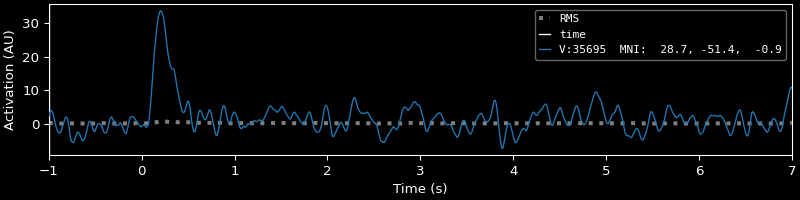

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


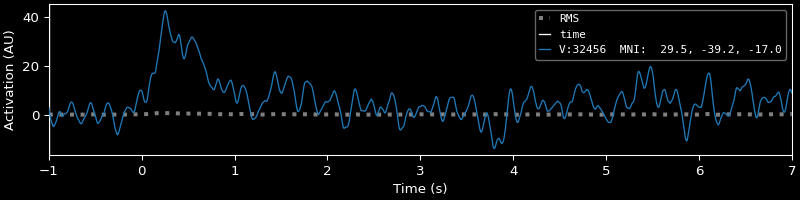

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


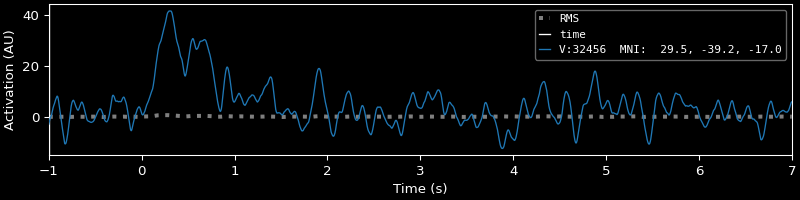

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [ ]:
if video_rendering == True:
    # Visualize activation in the hippocampus
    fname_src = fs_subjects_dir / patient / "bem" / f"{patient}-vol-5-src.fif"

    if not fname_src.exists():
        vol_src = mne.setup_volume_source_space(
            fs_subject,
            pos=5.0,
            subjects_dir=str(fs_subjects_dir),
            verbose=True,
        )
        mne.write_source_spaces(fname_src, vol_src, overwrite=True)
    else:
        vol_src = mne.read_source_spaces(fname_src)

    diff = mne.combine_evoked([cond_distant_past, cond_distant_futur], weights=[1, -1])

    evoked = [cond_current, cond_past, cond_futur, cond_never, cond_always, cond_distant_past, cond_distant_futur, diff]  # List of evoked objects for each condition
    evoked_names = ['Current', 'Past', 'Futur', 'Never', 'Always', 'Distant Past', 'Distant Futur','Diff']

    # TODO: zoom the video on the hippocampus
    for i in range(len(evoked)):
        if i >= nb_videos: # how many videos to render
            break

        cond = evoked[i]
        name = evoked_names[i]
        #cond.pick(picks_hip)  # Keep only the channels of interest
        stc = mne.stc_near_sensors(
            cond,
            trans,
            fs_subject,
            subjects_dir=subjects_dir,
            src=vol_src,
            surface=None,
            verbose="error",
        )
        #stc = abs(stc)  # just look at magnitude
        #clim = dict(kind="value", lims=np.percentile(cond.data, [-75, -50, -10, 10, 50, 75])
        threshold = np.percentile(np.abs(cond.data), 99)
        mid = np.percentile(np.abs(cond.data), 75)
        low = np.percentile(np.abs(cond.data), 10)

        clim = dict(kind="value", pos_lims=[low, mid, threshold])
        brain = stc.plot_3d(
            src=vol_src,
            subjects_dir=subjects_dir,
            view_layout="horizontal",
            views=["axial", "coronal", "sagittal"],
            size=(800, 300),
            show_traces=0.4,
            clim=clim,
            add_data_kwargs=dict(colorbar_kwargs=dict(label_font_size=8)),
        )
        brain.save_movie(time_dilation=3, interpolation='linear', framerate=24, time_viewer=True, filename=f'videos/{subject}/{reference}/new_filtering/{patient}_ieeg_{str(name)}_{reference}_70-200filt.mp4')

## Time frequency analysis

To be ignored for now

#### Frequency analysis

In [ ]:
if reference == "bipolar" :
    epochs_ref_for_psd = mne.set_bipolar_reference(
        epochs,
        ["TOD2", "TOD3", "PHD1", "PHD2", "PHD3", "PHD4", "HPD1", "HPD2", "HPD3", "HPD4", "HAD1", "HAD2", "HAD3"],
        ["TOD3", "TOD4", "PHD2", "PHD3", "PHD4", "PHD5", "HPD2", "HPD3", "HPD4", "HPD5", "HAD2", "HAD3", "HAD4"],
        ch_name=["TOD2-TOD3", "TOD3-TOD4", "PHD1-PHD2", "PHD2-PHD3", "PHD3-PHD4", "PHD4-PHD5", "HPD1-HPD2", "HPD2-HPD3", "HPD3-HPD4", "HPD4-HPD5", "HAD1-HAD2", "HAD2-HAD3", "HAD3-HAD4"]
    )
else:
    epochs_ref_for_psd = epochs_ref

sEEG channel type selected for re-referencing
Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Added the following bipolar channels:
TOD2-TOD3, TOD3-TOD4, PHD1-PHD2, PHD2-PHD3, PHD3-PHD4, PHD4-PHD5, HPD1-HPD2, HPD2-HPD3, HPD3-HPD4, HPD4-HPD5, HAD1-HAD2, HAD2-HAD3, HAD3-HAD4


In [ ]:
# Get the frequency spectrum at different stages of filtering
fmin, fmax = 0.1, 400

if reference == "bipolar":
    epochs_ref_for_psd.compute_psd(fmin=fmin, fmax=fmax).plot(
        average=True, amplitude=False, picks="data", exclude="bads"
    ).savefig(f"figures/{subject}/psd/{subject}_psd_{reference}_epochs_ref_for_psd.png", dpi=300)

# After epochs where referenced
epochs_ref.compute_psd(fmin=fmin, fmax=fmax).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/{subject}/psd/{subject}_psd_{reference}.png", dpi=300)

# Just after epochs are created
epochs.compute_psd(fmin=fmin, fmax=fmax).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/{subject}/psd/{subject}_psd_epochs.png", dpi=300)

# After data was loaded with no pre-processing
raw_for_psd = raw.copy().pick_channels(filtered_electrodes) 
raw_for_psd.compute_psd(fmin=fmin, fmax=fmax).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/{subject}/psd/{subject}_psd_raw.png", dpi=300)

# After the first filter (bandpass 0.1 - 250Hz)
raw_filtered.compute_psd(fmin=fmin, fmax=fmax).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/{subject}/psd/{subject}_psd_raw_filtered.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


In [ ]:
# More suited for eeg with all electrodes
epochs.compute_psd().plot_topomap(ch_type=None, normalize=False, contours=0).savefig(f"figures/{subject}/psd/{subject}_psd_topomap_{reference}.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


In [ ]:
_, ax = plt.subplots()
spectrum = epochs_ref.compute_psd(fmin=2.0, fmax=200.0, tmax=3.0, n_jobs=None)
# average across epochs first
mean_spectrum = spectrum.average()
psds, freqs = mean_spectrum.get_data(return_freqs=True)
# then convert to dB and take mean & standard deviation across channels
psds = 10 * np.log10(psds)
psds_mean = psds.mean(axis=0)
psds_std = psds.std(axis=0)

ax.plot(freqs, psds_mean, color="k")
ax.fill_between(
    freqs,
    psds_mean - psds_std,
    psds_mean + psds_std,
    color="k",
    alpha=0.5,
    edgecolor="none",
)
ax.set(
    title="Multitaper PSD (gradiometers)",
    xlabel="Frequency (Hz)",
    ylabel="Power Spectral Density (dB)",
)

ax.figure.savefig(f"figures/{subject}/psd/{subject}_psd_multitaper_{reference}.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows


#### Time-frequency analysis

In [ ]:
freqs = np.logspace(*np.log10([6, 35]), num=8)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power, itc = epochs_ref.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=True,
    decim=3,
)

#### Power

In [ ]:
power.plot_topo(baseline=(-0.5, 0), mode="logratio", title="Average power")
power.plot(picks=[10], baseline=(-0.5, 0), mode="logratio", title=power.ch_names[10])

fig, axes = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
topomap_kw = dict(
    ch_type=None, tmin=0.5, tmax=1.5, baseline=(-0.5, 0), mode="logratio", show=False
)
plot_dict = dict(Alpha=dict(fmin=8, fmax=12), Beta=dict(fmin=13, fmax=25))
for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    power.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)
fig.savefig(f"figures/{subject}/psd/{subject}_tfr_topomap_{reference}.png", dpi=300)

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


/home/aboschun/.conda/envs/miplab/lib/python3.14/site-packages/mne/viz/topo.py:337: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(layout=None)


Applying baseline correction (mode: logratio)


In [ ]:
power.plot_joint(
    baseline=(-0.5, 0), mode="mean", tmin=-0.5, tmax=2, timefreqs=[(0.5, 10), (1.3, 8)]
).savefig(f"figures/{subject}/psd/{subject}_tfr_joint_{reference}.png", dpi=300)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
